# Weather Forecasting using Python

Weather forecasting is the task of forecasting weather conditions for a given location and time. With the use of weather data and algorithms, it is possible to predict weather conditions for the next n number of days.

For forecasting weather using Python, we need a dataset containing historical weather data based on a particular location. I found a dataset on Kaggle based on the Daily weather data of New Delhi.

Now let’s start this task by importing the necessary Python libraries and the dataset we need:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
data_train=pd.read_csv("DailyDelhiClimateTrain.csv")
data_train.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [4]:
data_train.tail()

,date,meantemp,humidity,wind_speed,meanpressure
1457,2016-12-28,17.217391,68.043478,3.547826,1015.565217
1458,2016-12-29,15.238095,87.857143,6.000000,1016.904762
1459,2016-12-30,14.095238,89.666667,6.266667,1017.904762
1460,2016-12-31,15.052632,87.000000,7.325000,1016.100000
1461,2017-01-01,10.000000,100.000000,0.000000,1016.000000


Let’s have a look at the descriptive statistics of this data before moving forward:

In [5]:
data_train.describe()

,meantemp,humidity,wind_speed,meanpressure
count,1462.000000,1462.000000,1462.000000,1462.000000
mean,25.495521,60.771702,6.802209,1011.104548
std,7.348103,16.769652,4.561602,180.231668
min,6.000000,13.428571,0.000000,-3.041667
25%,18.857143,50.375000,3.475000,1001.580357
50%,27.714286,62.625000,6.221667,1008.563492
75%,31.305804,72.218750,9.238235,1014.944901
max,38.714286,100.000000,42.220000,7679.333333


Now let’s have a look at the information about all the columns in the dataset:

In [6]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB


In [7]:
data_test=pd.read_csv("DailyDelhiClimateTest.csv")
data_test.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333


In [8]:
data_test.tail()

,date,meantemp,humidity,wind_speed,meanpressure
109,2017-04-20,34.500,27.500000,5.562500,998.625000
110,2017-04-21,34.250,39.375000,6.962500,999.875000
111,2017-04-22,32.900,40.900000,8.890000,1001.600000
112,2017-04-23,32.875,27.500000,9.962500,1002.125000
113,2017-04-24,32.000,27.142857,12.157143,1004.142857


In [9]:
data_test.describe()

,meantemp,humidity,wind_speed,meanpressure
count,114.000000,114.000000,114.000000,114.000000
mean,21.713079,56.258362,8.143924,1004.035090
std,6.360072,19.068083,3.588049,89.474692
min,11.000000,17.750000,1.387500,59.000000
25%,16.437198,39.625000,5.563542,1007.437500
50%,19.875000,57.750000,8.069444,1012.739316
75%,27.705357,71.902778,10.068750,1016.739583
max,34.500000,95.833333,19.314286,1022.809524


In [10]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          114 non-null    object 
 1   meantemp      114 non-null    float64
 2   humidity      114 non-null    float64
 3   wind_speed    114 non-null    float64
 4   meanpressure  114 non-null    float64
dtypes: float64(4), object(1)
memory usage: 4.6+ KB


The date column in this dataset is not having a datetime data type. We will change it when required. Let’s have a look at the mean temperature in Delhi over the years:

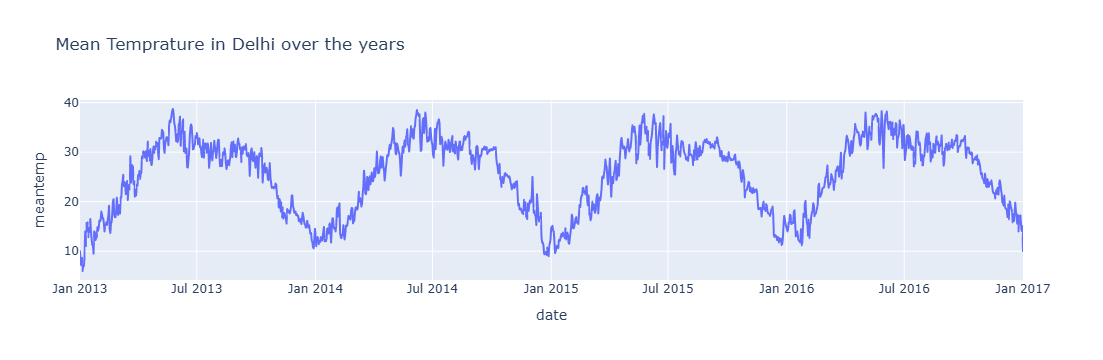

In [11]:
figure=px.line(data_train, x="date", y="meantemp", title="Mean Temprature in Delhi over the years")
figure.show()

Now let’s have a look at the humidity in Delhi over the years:

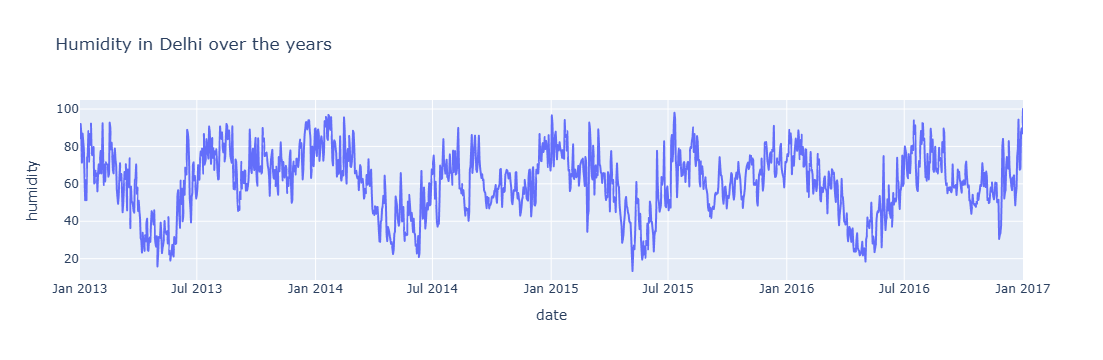

In [12]:
figure=px.line(data_train, x="date", y="humidity", title="Humidity in Delhi over the years")
figure.show()

Now let’s have a look at the wind speed in Delhi over the years:

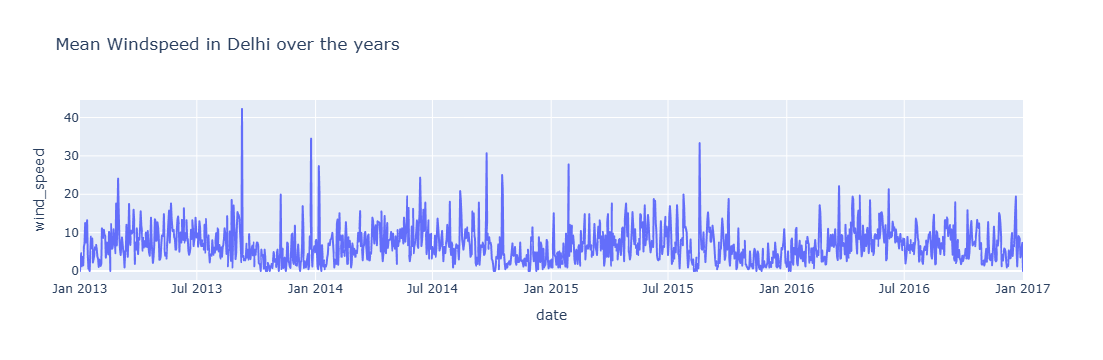

In [13]:
figure=px.line(data_train, x="date", y="wind_speed", title="Mean Windspeed in Delhi over the years")
figure.show()

Till 2015, the wind speed was higher during monsoons (August & September) and retreating monsoons (December & January). After 2015, there were no anomalies in wind speed during monsoons. Now let’s have a look at the relationship between temperature and humidity:

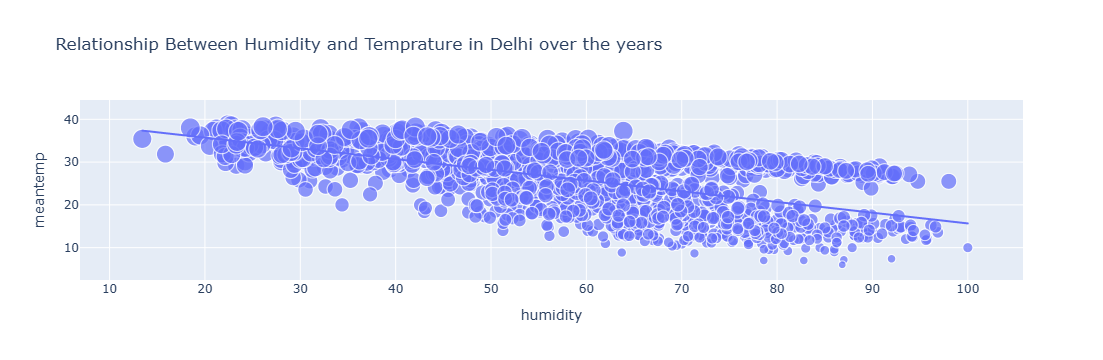

In [14]:
figure=px.scatter(data_train, x="humidity", y="meantemp", size="meantemp", trendline="ols", title="Relationship Between Humidity and Temprature in Delhi over the years")
figure.show()

There’s a negative correlation between temperature and humidity in Delhi. It means higher temperature results in low humidity and lower temperature results in high humidity.

## Analyzing Temperature Change

Now let’s analyze the temperature change in Delhi over the years. For this task, I will first convert the data type of the date column into datetime. Then I will add two new columns in the dataset for year and month values.

Here’s how we can change the data type and extract year and month data from the date column:

In [15]:
data_train["date"] = pd.to_datetime(data_train["date"], errors='coerce')

# Drop rows where the conversion failed
data_train = data_train.dropna(subset=["date"])

# Extract year and month
data_train["year"] = data_train["date"].dt.year
data_train["month"] = data_train["date"].dt.month

data_train.head()

,date,meantemp,humidity,wind_speed,meanpressure,year,month
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667,2013,1
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000,2013,1
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667,2013,1
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667,2013,1
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000,2013,1


In [16]:
data_test["date"] = pd.to_datetime(data_test["date"], errors='coerce')

# Drop rows where the conversion failed
data_test = data_test.dropna(subset=["date"])

# Extract year and month
data_test["year"] = data_test["date"].dt.year
data_test["month"] = data_test["date"].dt.month

data_test.head()

,date,meantemp,humidity,wind_speed,meanpressure,year,month
0,2017-01-01,15.913043,85.869565,2.743478,59.000000,2017,1
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778,2017,1
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333,2017,1
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000,2017,1
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333,2017,1


Now let’s have a look at the temperature change in Delhi over the years:

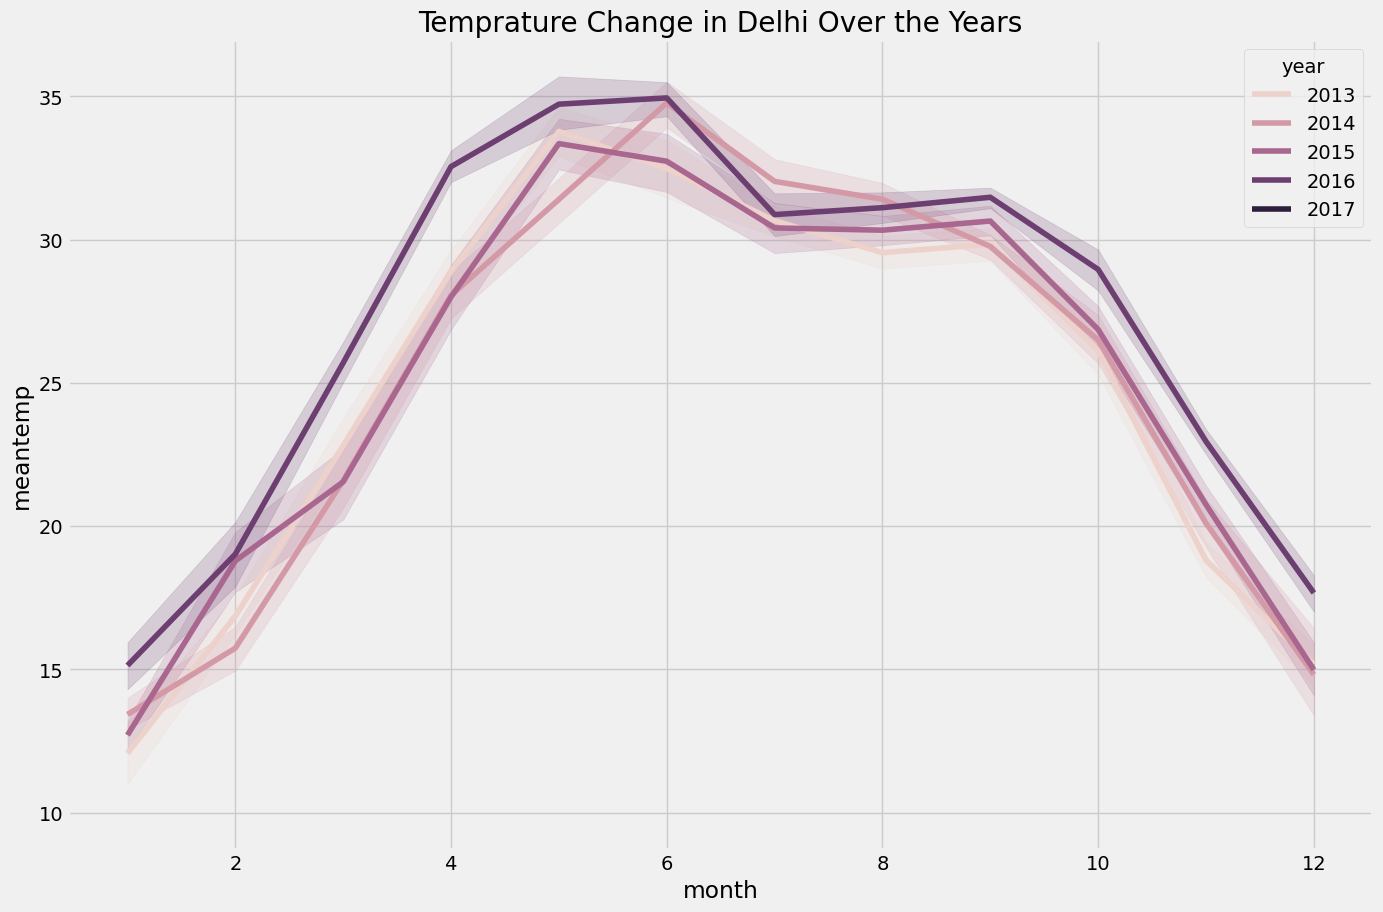

In [17]:
plt.style.use("fivethirtyeight")
plt.figure(figsize=(15,10))
plt.title("Temprature Change in Delhi Over the Years")
sns.lineplot(data_train, x="month", y="meantemp", hue="year")
plt.show()

Although 2017 was not the hottest year in the summer, we can see a rise in the average temperature of Delhi every year.

## Forecasting Weather using Python
Now let’s move to the task of weather forecasting. I will be using the Facebook prophet model for this task. The Facebook prophet model is one of the best techniques for time series forecasting. If you have never used this model before, you can install it on your system by using the command mentioned below in your command prompt or terminal:

pip install prophet
The prophet model accepts time data named as “ds”, and labels as “y”. So let’s convert the data into this format:

In [18]:
forecast_data=data_train.rename(columns={"date":"ds", "meantemp":"y"})
print(forecast_data)

             ds          y    humidity  wind_speed  meanpressure  year  month
0    2013-01-01  10.000000   84.500000    0.000000   1015.666667  2013      1
1    2013-01-02   7.400000   92.000000    2.980000   1017.800000  2013      1
2    2013-01-03   7.166667   87.000000    4.633333   1018.666667  2013      1
3    2013-01-04   8.666667   71.333333    1.233333   1017.166667  2013      1
4    2013-01-05   6.000000   86.833333    3.700000   1016.500000  2013      1
...         ...        ...         ...         ...           ...   ...    ...
1457 2016-12-28  17.217391   68.043478    3.547826   1015.565217  2016     12
1458 2016-12-29  15.238095   87.857143    6.000000   1016.904762  2016     12
1459 2016-12-30  14.095238   89.666667    6.266667   1017.904762  2016     12
1460 2016-12-31  15.052632   87.000000    7.325000   1016.100000  2016     12
1461 2017-01-01  10.000000  100.000000    0.000000   1016.000000  2017      1

[1462 rows x 7 columns]


Now below is how we can use the Facebook prophet model for weather forecasting using Python:

23:02:48 - cmdstanpy - INFO - Chain [1] start processing
23:02:49 - cmdstanpy - INFO - Chain [1] done processing


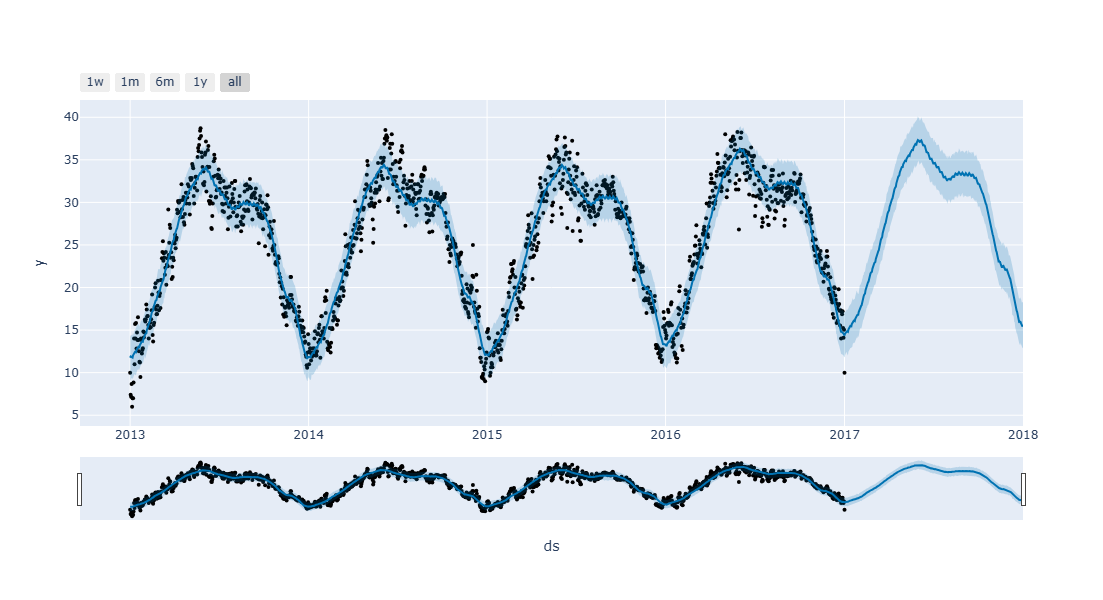

In [19]:
model=Prophet()
model.fit(forecast_data)
forecasts=model.make_future_dataframe(periods=365)
predictions=model.predict(forecasts)
plot_plotly(model, predictions)

So this is how you can analyze and forecast the weather using Python.

In [20]:
print(predictions)

             ds      trend  yhat_lower  yhat_upper  trend_lower  trend_upper  \
0    2013-01-01  24.689997    9.099050   14.397029    24.689997    24.689997   
1    2013-01-02  24.690142    9.074743   14.302813    24.690142    24.690142   
2    2013-01-03  24.690287    9.281314   14.454602    24.690287    24.690287   
3    2013-01-04  24.690432    9.368322   14.359645    24.690432    24.690432   
4    2013-01-05  24.690577    9.390012   14.345158    24.690577    24.690577   
...         ...        ...         ...         ...          ...          ...   
1822 2017-12-28  28.583674   13.337867   18.611330    27.988594    29.159005   
1823 2017-12-29  28.586590   13.185273   18.464555    27.989366    29.164364   
1824 2017-12-30  28.589506   13.060574   18.190579    27.990138    29.168947   
1825 2017-12-31  28.592422   12.866908   18.297260    27.990910    29.173381   
1826 2018-01-01  28.595337   12.966649   18.300561    27.991683    29.177890   

      additive_terms  additive_terms_lo

### Setting date col as an index

In [21]:
date_train_date=data_train["date"]
date_train_date.head()

0   2013-01-01
1   2013-01-02
2   2013-01-03
3   2013-01-04
4   2013-01-05
Name: date, dtype: datetime64[ns]

In [22]:
date_test_date=data_test["date"]
date_test_date.head()

0   2017-01-01
1   2017-01-02
2   2017-01-03
3   2017-01-04
4   2017-01-05
Name: date, dtype: datetime64[ns]

In [23]:
data_train_date=data_train.set_index("date")

In [24]:
data_train_date.sample()

,meantemp,humidity,wind_speed,meanpressure,year,month
date,,,,,,
2016-06-17,34.1875,52.25,7.425,999.428571,2016,6


In [25]:
data_test_date=data_test.set_index("date")
data_test_date.sample()

,meantemp,humidity,wind_speed,meanpressure,year,month
date,,,,,,
2017-01-28,14.863636,82.772727,9.690909,1019.636364,2017,1


### Getting Year ,Month ,Day_name from the date

In [26]:
data_train_date["day_name"]=data_train_date.index.strftime("%A")
data_train_date

,meantemp,humidity,wind_speed,meanpressure,year,month,day_name
date,,,,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667,2013,1,Tuesday
2013-01-02,7.400000,92.000000,2.980000,1017.800000,2013,1,Wednesday
2013-01-03,7.166667,87.000000,4.633333,1018.666667,2013,1,Thursday
2013-01-04,8.666667,71.333333,1.233333,1017.166667,2013,1,Friday
2013-01-05,6.000000,86.833333,3.700000,1016.500000,2013,1,Saturday
...,...,...,...,...,...,...,...
2016-12-28,17.217391,68.043478,3.547826,1015.565217,2016,12,Wednesday
2016-12-29,15.238095,87.857143,6.000000,1016.904762,2016,12,Thursday
2016-12-30,14.095238,89.666667,6.266667,1017.904762,2016,12,Friday


In [27]:
data_test_date.head()

,meantemp,humidity,wind_speed,meanpressure,year,month
date,,,,,,
2017-01-01,15.913043,85.869565,2.743478,59.000000,2017,1
2017-01-02,18.500000,77.222222,2.894444,1018.277778,2017,1
2017-01-03,17.111111,81.888889,4.016667,1018.333333,2017,1
2017-01-04,18.700000,70.050000,4.545000,1015.700000,2017,1
2017-01-05,18.388889,74.944444,3.300000,1014.333333,2017,1


In [28]:
data_test_date['year'] = data_test_date.index.year
data_test_date['month'] = data_test_date.index.month

In [29]:
data_test_date["day_name"]=data_test_date.index.strftime("%A")
data_test_date.head()

,meantemp,humidity,wind_speed,meanpressure,year,month,day_name
date,,,,,,,
2017-01-01,15.913043,85.869565,2.743478,59.000000,2017,1,Sunday
2017-01-02,18.500000,77.222222,2.894444,1018.277778,2017,1,Monday
2017-01-03,17.111111,81.888889,4.016667,1018.333333,2017,1,Tuesday
2017-01-04,18.700000,70.050000,4.545000,1015.700000,2017,1,Wednesday
2017-01-05,18.388889,74.944444,3.300000,1014.333333,2017,1,Thursday


### Getting all data for a specific year

In [30]:
data_train_date.loc['2015']

,meantemp,humidity,wind_speed,meanpressure,year,month,day_name
date,,,,,,,
2015-01-01,14.750,72.000,0.9250,1017.500,2015,1,Thursday
2015-01-02,14.875,96.625,3.0125,1017.875,2015,1,Friday
2015-01-03,15.125,92.000,0.9250,1017.375,2015,1,Saturday
2015-01-04,14.125,78.750,9.5125,1019.625,2015,1,Sunday
2015-01-05,14.000,69.375,15.0500,1016.000,2015,1,Monday
...,...,...,...,...,...,...,...
2015-12-27,15.375,63.250,7.8875,1020.625,2015,12,Sunday
2015-12-28,17.125,58.125,10.8875,1020.875,2015,12,Monday
2015-12-29,16.375,65.000,7.4125,1018.125,2015,12,Tuesday


### Getting data for a Specific Period

In [31]:
data_train_date.loc['2014-01-01':'2014-02-01']

,meantemp,humidity,wind_speed,meanpressure,year,month,day_name
date,,,,,,,
2014-01-01,13.375000,89.625000,7.650000,1021.000000,2014,1,Wednesday
2014-01-02,11.000000,78.375000,8.100000,1020.250000,2014,1,Thursday
2014-01-03,12.500000,74.875000,5.325000,1017.750000,2014,1,Friday
2014-01-04,12.875000,88.125000,1.162500,1016.250000,2014,1,Saturday
2014-01-05,12.375000,89.000000,0.462500,1014.500000,2014,1,Sunday
2014-01-06,11.428571,86.285714,27.337500,1017.625000,2014,1,Monday
2014-01-07,12.142857,72.285714,20.600000,1017.750000,2014,1,Tuesday
2014-01-08,11.875000,76.875000,1.850000,1017.875000,2014,1,Wednesday
2014-01-09,12.833333,83.000000,1.233333,1017.000000,2014,1,Thursday


### Plotting Time Series Data

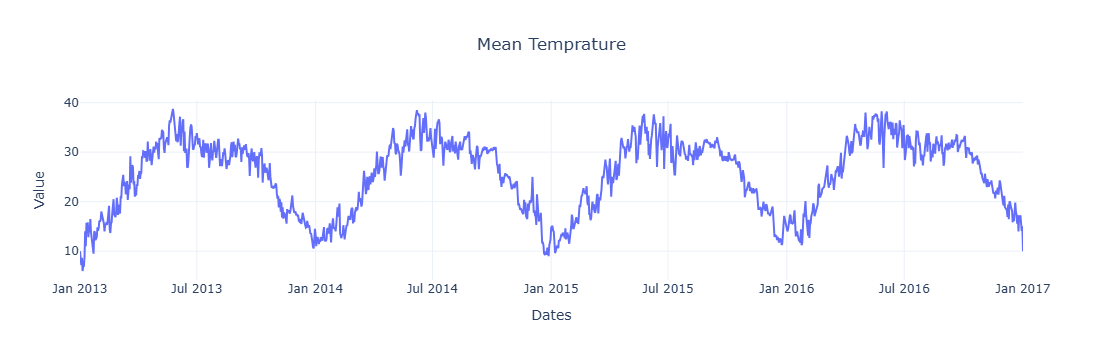

In [32]:
fig_temp=go.Figure()
fig_temp.add_trace(go.Scatter(x=data_train_date.index, y=data_train_date["meantemp"], mode="lines"))
fig_temp.update_layout(title="Mean Temprature", xaxis_title="Dates", yaxis_title="Value", template="plotly_white", title_x=0.5)
fig_temp.show()

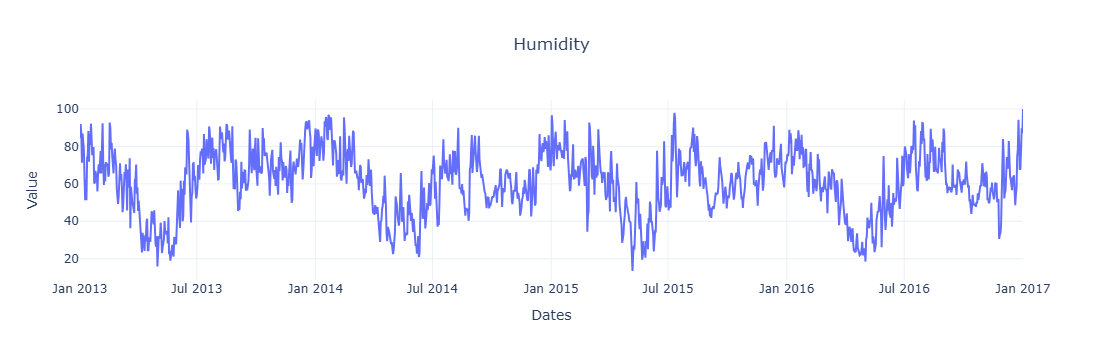

In [33]:
fig_temp=go.Figure()
fig_temp.add_trace(go.Scatter(x=data_train_date.index, y=data_train_date["humidity"], mode="lines"))
fig_temp.update_layout(title="Humidity", xaxis_title="Dates", yaxis_title="Value", template="plotly_white", title_x=0.5)
fig_temp.show()

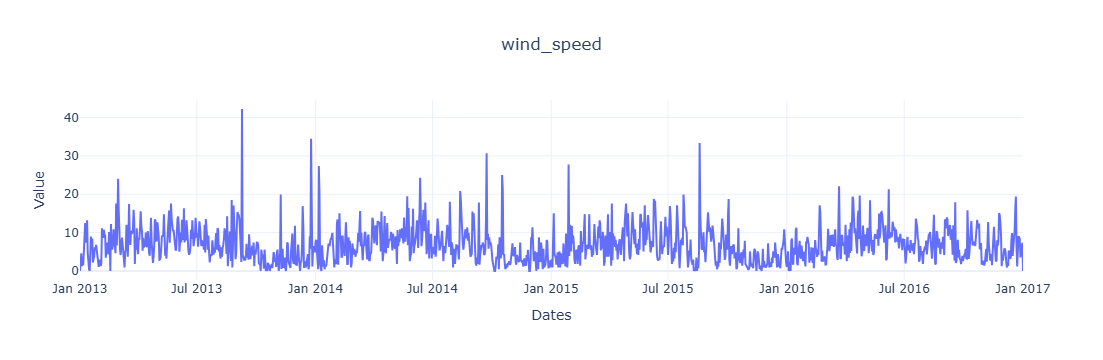

In [34]:
fig_temp=go.Figure()
fig_temp.add_trace(go.Scatter(x=data_train_date.index, y=data_train_date["wind_speed"], mode="lines"))
fig_temp.update_layout(title="wind_speed", xaxis_title="Dates", yaxis_title="Value", template="plotly_white", title_x=0.5)
fig_temp.show()

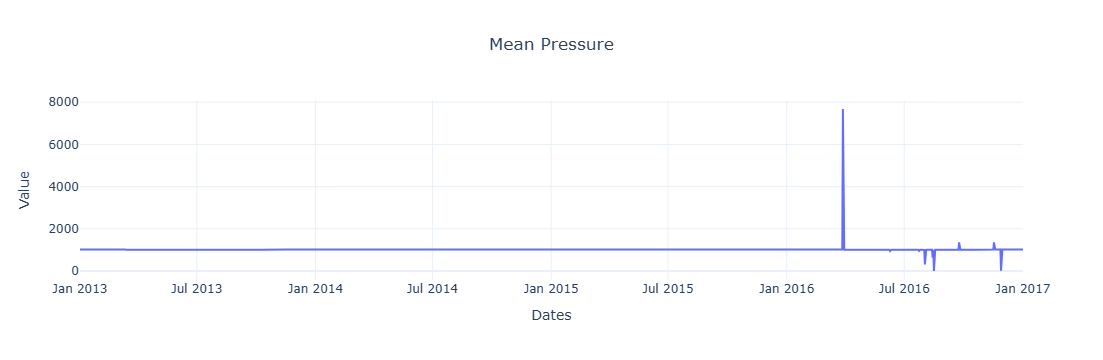

In [35]:
fig_temp=go.Figure()
fig_temp.add_trace(go.Scatter(x=data_train_date.index, y=data_train_date["meanpressure"], mode="lines"))
fig_temp.update_layout(title="Mean Pressure", xaxis_title="Dates", yaxis_title="Value", template="plotly_white", title_x=0.5)
fig_temp.show()

### 2013 Vs 2016

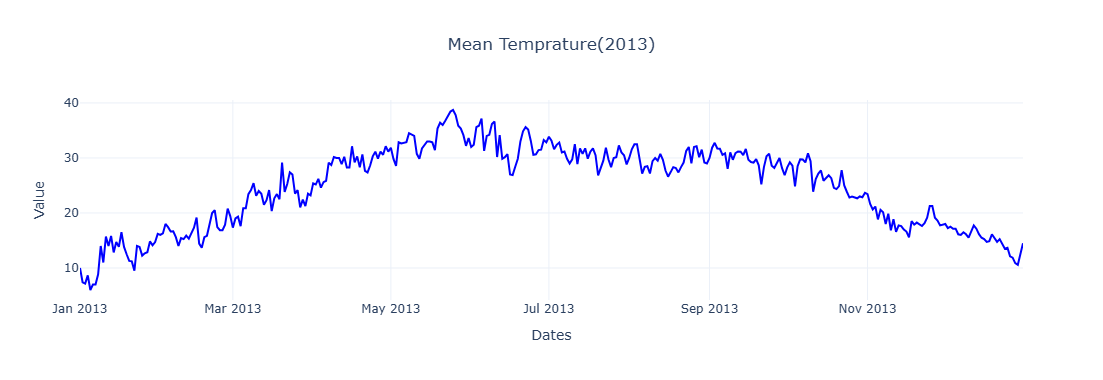

In [36]:
figure_temp_2013=go.Figure()
figure_temp_2013.add_trace(go.Scatter(x=data_train_date.loc["2013", :].index, y=data_train_date.loc["2013", "meantemp"], mode="lines", line=dict(color="blue")))
figure_temp_2013.update_layout(title="Mean Temprature(2013)", xaxis_title="Dates", yaxis_title="Value", template="plotly_white", title_x=0.5, height=380)
figure_temp_2013.show()

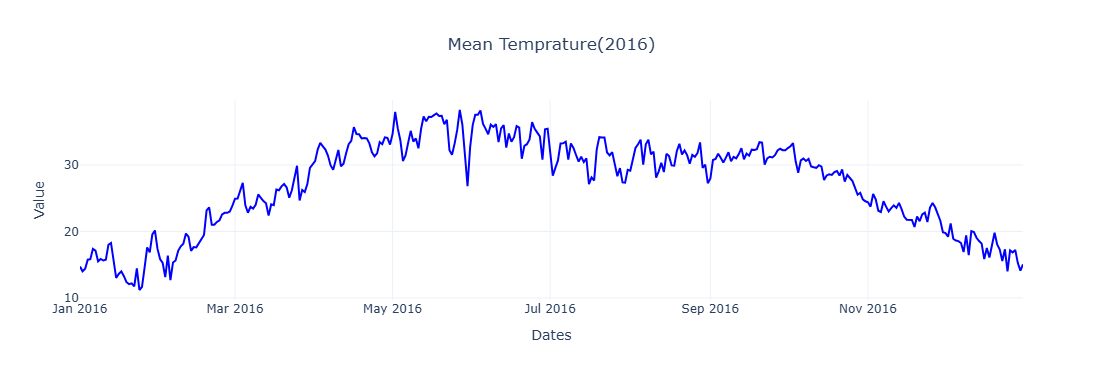

In [37]:
figure_temp_2016=go.Figure()
figure_temp_2016.add_trace(go.Scatter(x=data_train_date.loc["2016", :].index, y=data_train_date.loc["2016", "meantemp"], mode="lines", line=dict(color="blue")))
figure_temp_2016.update_layout(title="Mean Temprature(2016)", xaxis_title="Dates", yaxis_title="Value", template="plotly_white", title_x=0.5, height=380)
figure_temp_2016.show()

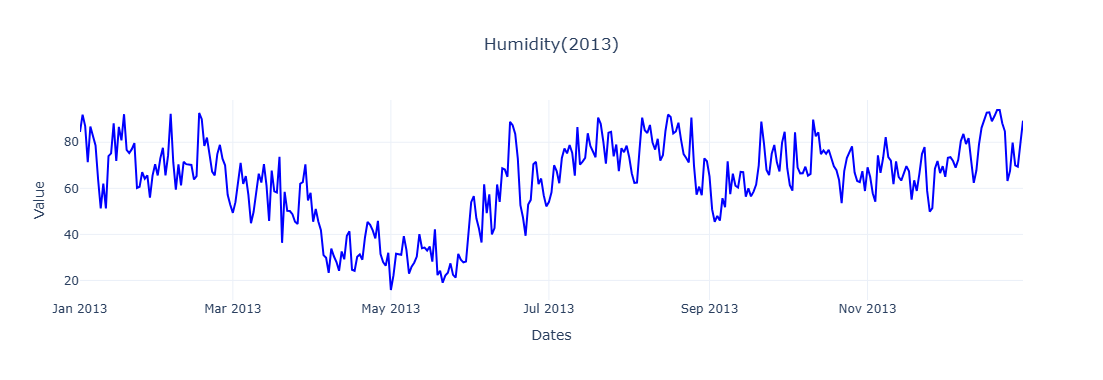

In [38]:
figure_humidity_2013=go.Figure()
figure_humidity_2013.add_trace(go.Scatter(x=data_train_date.loc["2013", :].index, y=data_train_date.loc["2013", "humidity"], mode="lines", line=dict(color="blue")))
figure_humidity_2013.update_layout(title="Humidity(2013)", xaxis_title="Dates", yaxis_title="Value", template="plotly_white", title_x=0.5, height=380)
figure_humidity_2013.show()

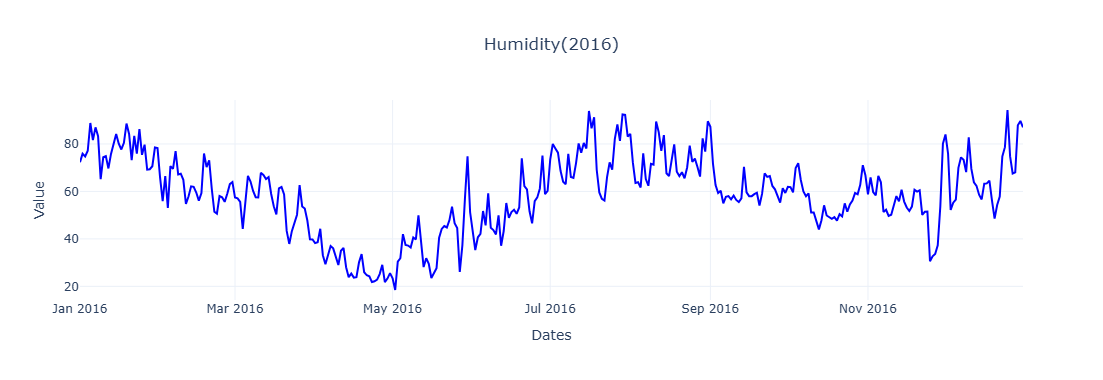

In [39]:
figure_humidity_2016=go.Figure()
figure_humidity_2016.add_trace(go.Scatter(x=data_train_date.loc["2016", :].index, y=data_train_date.loc["2016", "humidity"], mode="lines", line=dict(color="blue")))
figure_humidity_2016.update_layout(title="Humidity(2016)", xaxis_title="Dates", yaxis_title="Value", template="plotly_white", title_x=0.5, height=380)
figure_humidity_2016.show()

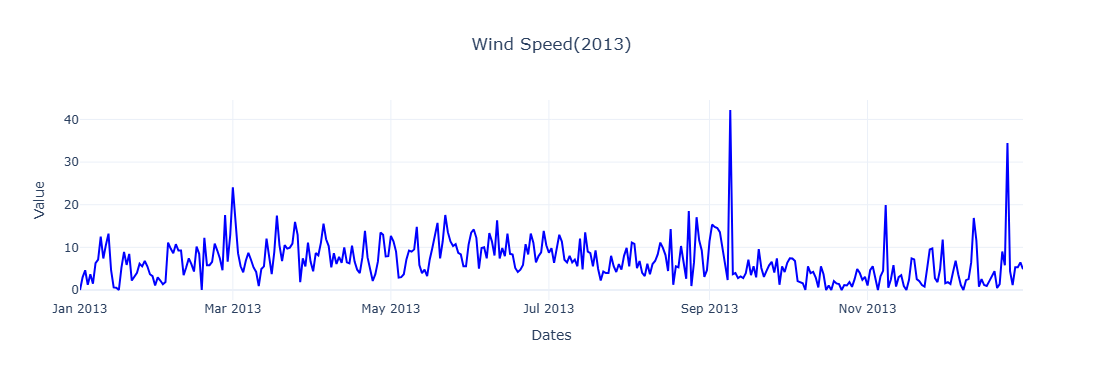

In [40]:
figure_wind_speed_2013=go.Figure()
figure_wind_speed_2013.add_trace(go.Scatter(x=data_train_date.loc["2013", :].index, y=data_train_date.loc["2013", "wind_speed"], mode="lines", line=dict(color="blue")))
figure_wind_speed_2013.update_layout(title="Wind Speed(2013)", xaxis_title="Dates", yaxis_title="Value", template="plotly_white", title_x=0.5, height=380)
figure_wind_speed_2013.show()

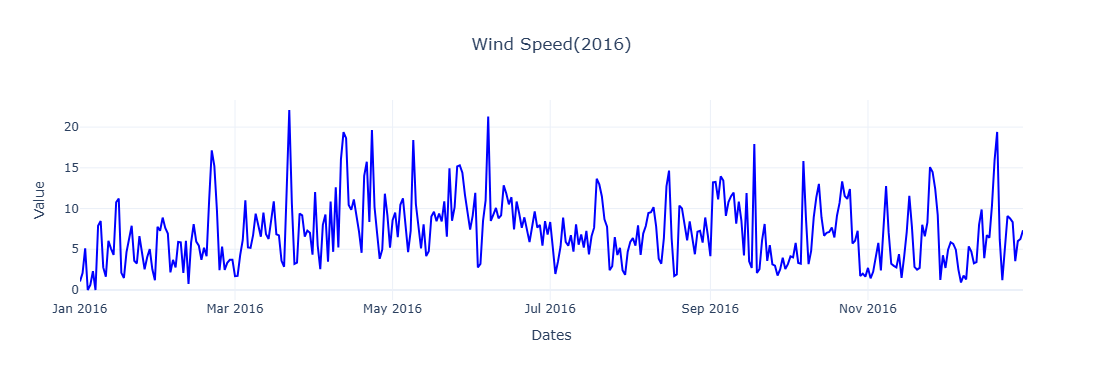

In [41]:
figure_wind_speed_2016=go.Figure()
figure_wind_speed_2016.add_trace(go.Scatter(x=data_train_date.loc["2016", :].index, y=data_train_date.loc["2016", "wind_speed"], mode="lines", line=dict(color="blue")))
figure_wind_speed_2016.update_layout(title="Wind Speed(2016)", xaxis_title="Dates", yaxis_title="Value", template="plotly_white", title_x=0.5, height=380)
figure_wind_speed_2016.show()

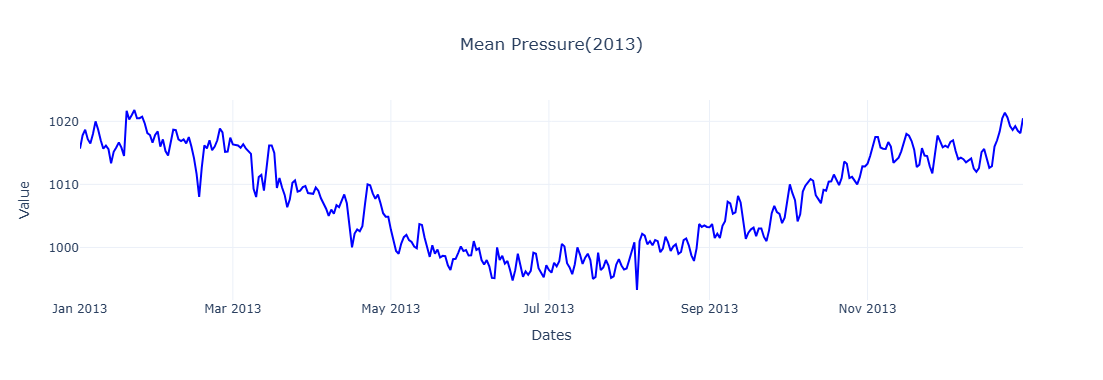

In [42]:
figure_meanpressure_2013=go.Figure()
figure_meanpressure_2013.add_trace(go.Scatter(x=data_train_date.loc["2013", :].index, y=data_train_date.loc["2013", "meanpressure"], mode="lines", line=dict(color="blue")))
figure_meanpressure_2013.update_layout(title="Mean Pressure(2013)", xaxis_title="Dates", yaxis_title="Value", template="plotly_white", title_x=0.5, height=380)
figure_meanpressure_2013.show()

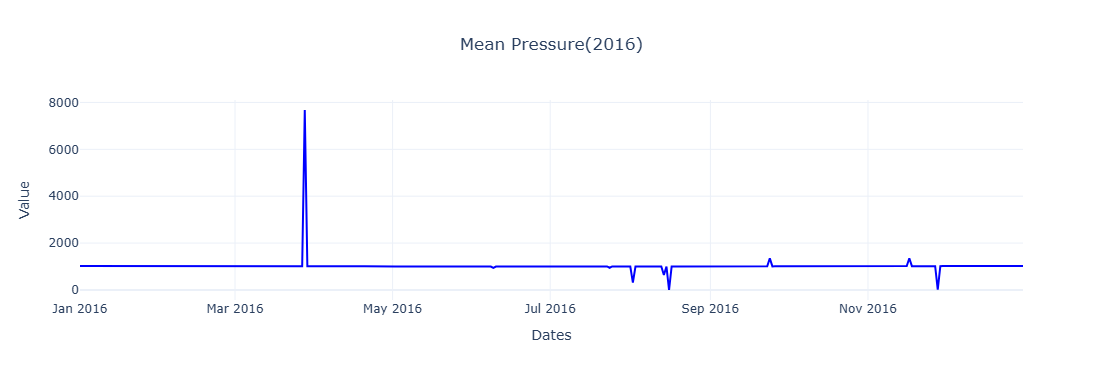

In [43]:
figure_meanpressure_2016=go.Figure()
figure_meanpressure_2016.add_trace(go.Scatter(x=data_train_date.loc["2016", :].index, y=data_train_date.loc["2016", "meanpressure"], mode="lines", line=dict(color="blue")))
figure_meanpressure_2016.update_layout(title="Mean Pressure(2016)", xaxis_title="Dates", yaxis_title="Value", template="plotly_white", title_x=0.5, height=380)
figure_meanpressure_2016.show()

## Preprocessing

In [44]:
data_train_date.dtypes

meantemp        float64
humidity        float64
wind_speed      float64
meanpressure    float64
year              int32
month             int32
day_name         object
dtype: object

### Dropping unnermical col

In [45]:
data_train_numerical=data_train_date.drop(columns=["day_name"])

In [46]:
data_train_numerical.head()

,meantemp,humidity,wind_speed,meanpressure,year,month
date,,,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667,2013,1
2013-01-02,7.400000,92.000000,2.980000,1017.800000,2013,1
2013-01-03,7.166667,87.000000,4.633333,1018.666667,2013,1
2013-01-04,8.666667,71.333333,1.233333,1017.166667,2013,1
2013-01-05,6.000000,86.833333,3.700000,1016.500000,2013,1


In [47]:
data_train_numerical.columns

Index(['meantemp', 'humidity', 'wind_speed', 'meanpressure', 'year', 'month'], dtype='object')

In [48]:
data_test_numerical=data_test_date.drop(columns=["day_name"])

In [49]:
data_test_numerical.head()

,meantemp,humidity,wind_speed,meanpressure,year,month
date,,,,,,
2017-01-01,15.913043,85.869565,2.743478,59.000000,2017,1
2017-01-02,18.500000,77.222222,2.894444,1018.277778,2017,1
2017-01-03,17.111111,81.888889,4.016667,1018.333333,2017,1
2017-01-04,18.700000,70.050000,4.545000,1015.700000,2017,1
2017-01-05,18.388889,74.944444,3.300000,1014.333333,2017,1


In [50]:
data_test_numerical.columns

Index(['meantemp', 'humidity', 'wind_speed', 'meanpressure', 'year', 'month'], dtype='object')

### Normalizing

In [51]:
scl= StandardScaler()
data_train_scl=scl.fit_transform(data_train_numerical)
data_test_scl=scl.fit_transform(data_test_numerical)

In [52]:
type(data_train_scl)

numpy.ndarray

### Convert noramlized data from numpy to dataframe

In [53]:
data_train_scl=pd.DataFrame(data_train_scl)
data_train_scl

,0,1,2,3,4,5
0,-2.109500,1.415439,-1.491699,0.025321,-1.341891,-1.599501
1,-2.463454,1.862828,-0.838196,0.037162,-1.341891,-1.599501
2,-2.495219,1.564569,-0.475626,0.041972,-1.341891,-1.599501
3,-2.291015,0.630022,-1.221233,0.033647,-1.341891,-1.599501
4,-2.654044,1.554627,-0.680303,0.029946,-1.341891,-1.599501
...,...,...,...,...,...,...
1457,-1.126952,0.433776,-0.713674,0.024758,1.337005,1.588400
1458,-1.396406,1.615699,-0.175921,0.032193,1.337005,1.588400
1459,-1.551990,1.723641,-0.117442,0.037743,1.337005,1.588400
1460,-1.421654,1.564569,0.114646,0.027726,1.337005,1.588400


In [54]:
data_test_scl=pd.DataFrame(data_test_scl)
data_test_scl

,0,1,2,3,4,5
0,-0.915971,1.559776,-1.511765,-10.608670,0.0,-1.292571
1,-0.507426,1.104275,-1.469505,0.159884,0.0,-1.292571
2,-0.726766,1.350093,-1.155357,0.160508,0.0,-1.292571
3,-0.475841,0.726477,-1.007459,0.130947,0.0,-1.292571
4,-0.524973,0.984293,-1.355976,0.115605,0.0,-1.292571
...,...,...,...,...,...,...
109,2.019376,-1.514852,-0.722627,-0.060732,0.0,1.436191
110,1.979895,-0.889334,-0.330720,-0.046700,0.0,1.436191
111,1.766696,-0.809005,0.208852,-0.027336,0.0,1.436191
112,1.762748,-1.514852,0.509080,-0.021442,0.0,1.436191


### Rename cols

In [55]:
data_train_scl.rename(columns={0: "meantemp", 1:"humidity", 2:"windspeed", 3:"meanpressure", 4:"year", 5:"month"}, inplace=True)
data_train_scl.head()

,meantemp,humidity,windspeed,meanpressure,year,month
0,-2.109500,1.415439,-1.491699,0.025321,-1.341891,-1.599501
1,-2.463454,1.862828,-0.838196,0.037162,-1.341891,-1.599501
2,-2.495219,1.564569,-0.475626,0.041972,-1.341891,-1.599501
3,-2.291015,0.630022,-1.221233,0.033647,-1.341891,-1.599501
4,-2.654044,1.554627,-0.680303,0.029946,-1.341891,-1.599501


In [56]:
data_test_scl.rename(columns={0: "meantemp", 1:"humidity", 2:"windspeed", 3:"meanpressure", 4:"year", 5:"month"}, inplace=True)
data_test_scl.head()

,meantemp,humidity,windspeed,meanpressure,year,month
0,-0.915971,1.559776,-1.511765,-10.608670,0.0,-1.292571
1,-0.507426,1.104275,-1.469505,0.159884,0.0,-1.292571
2,-0.726766,1.350093,-1.155357,0.160508,0.0,-1.292571
3,-0.475841,0.726477,-1.007459,0.130947,0.0,-1.292571
4,-0.524973,0.984293,-1.355976,0.115605,0.0,-1.292571


Add date as a col to df then make it as index

In [57]:
data_date_train=pd.DataFrame({"date_train": date_train_date})
data_train_scl=pd.concat([data_train_scl,data_date_train], axis=1) 
data_train_scl.head()

,meantemp,humidity,windspeed,meanpressure,year,month,date_train
0,-2.109500,1.415439,-1.491699,0.025321,-1.341891,-1.599501,2013-01-01
1,-2.463454,1.862828,-0.838196,0.037162,-1.341891,-1.599501,2013-01-02
2,-2.495219,1.564569,-0.475626,0.041972,-1.341891,-1.599501,2013-01-03
3,-2.291015,0.630022,-1.221233,0.033647,-1.341891,-1.599501,2013-01-04
4,-2.654044,1.554627,-0.680303,0.029946,-1.341891,-1.599501,2013-01-05


In [58]:
data_train_scl.columns

Index(['meantemp', 'humidity', 'windspeed', 'meanpressure', 'year', 'month',
       'date_train'],
      dtype='object')

In [59]:
data_train_scl.set_index("date_train", inplace=True)
print(data_train_scl)

            meantemp  humidity  windspeed  meanpressure      year     month
date_train                                                                 
2013-01-01 -2.109500  1.415439  -1.491699      0.025321 -1.341891 -1.599501
2013-01-02 -2.463454  1.862828  -0.838196      0.037162 -1.341891 -1.599501
2013-01-03 -2.495219  1.564569  -0.475626      0.041972 -1.341891 -1.599501
2013-01-04 -2.291015  0.630022  -1.221233      0.033647 -1.341891 -1.599501
2013-01-05 -2.654044  1.554627  -0.680303      0.029946 -1.341891 -1.599501
...              ...       ...        ...           ...       ...       ...
2016-12-28 -1.126952  0.433776  -0.713674      0.024758  1.337005  1.588400
2016-12-29 -1.396406  1.615699  -0.175921      0.032193  1.337005  1.588400
2016-12-30 -1.551990  1.723641  -0.117442      0.037743  1.337005  1.588400
2016-12-31 -1.421654  1.564569   0.114646      0.027726  1.337005  1.588400
2017-01-01 -2.109500  2.340044  -1.491699      0.027171  2.229970 -1.599501

[1462 rows 

In [60]:
data_date_test=pd.DataFrame({"date_test": date_test_date})
data_test_scl=pd.concat([data_test_scl,data_date_test], axis=1) 
data_test_scl.head()

,meantemp,humidity,windspeed,meanpressure,year,month,date_test
0,-0.915971,1.559776,-1.511765,-10.608670,0.0,-1.292571,2017-01-01
1,-0.507426,1.104275,-1.469505,0.159884,0.0,-1.292571,2017-01-02
2,-0.726766,1.350093,-1.155357,0.160508,0.0,-1.292571,2017-01-03
3,-0.475841,0.726477,-1.007459,0.130947,0.0,-1.292571,2017-01-04
4,-0.524973,0.984293,-1.355976,0.115605,0.0,-1.292571,2017-01-05


In [61]:
data_test_scl.columns

Index(['meantemp', 'humidity', 'windspeed', 'meanpressure', 'year', 'month',
       'date_test'],
      dtype='object')

## AutoReg Model (Predict wind speed)

### Extract the endogenous variable(wind speed)

In [62]:
wind_train=data_train_scl["windspeed"]
wind_train

date_train
2013-01-01   -1.491699
2013-01-02   -0.838196
2013-01-03   -0.475626
2013-01-04   -1.221233
2013-01-05   -0.680303
                ...   
2016-12-28   -0.713674
2016-12-29   -0.175921
2016-12-30   -0.117442
2016-12-31    0.114646
2017-01-01   -1.491699
Name: windspeed, Length: 1462, dtype: float64

In [63]:
wind_test=data_train_scl["windspeed"]
wind_test

date_train
2013-01-01   -1.491699
2013-01-02   -0.838196
2013-01-03   -0.475626
2013-01-04   -1.221233
2013-01-05   -0.680303
                ...   
2016-12-28   -0.713674
2016-12-29   -0.175921
2016-12-30   -0.117442
2016-12-31    0.114646
2017-01-01   -1.491699
Name: windspeed, Length: 1462, dtype: float64

### Train the AR model

In [64]:
lag_order=180
ar_model_wind=AutoReg(wind_train, lags=lag_order)
model_fit=ar_model_wind.fit()

C:\Users\Sravan Tummalapalli\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



### Make predictions

In [65]:
predictions=model_fit.predict(start=len(wind_train), end=len(wind_train)+len(wind_test)-1, dynamic=False)

C:\Users\Sravan Tummalapalli\anaconda3\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning:

Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.



### Evaluate the model

In [66]:
mse_wind=mean_squared_error(wind_train, predictions)
print(f'Mean Squared Error:{mse_wind:5f}')

Mean Squared Error:0.971602


In [67]:
mae_wind=mean_absolute_error(wind_train, predictions)
print(f'Mean Absolute Error:{mae_wind:5f}')

Mean Absolute Error:0.742569


In [68]:
rsme_wind=mean_squared_error(wind_train, predictions, squared=False)
print(f'Root Mean Squared Error:{rsme_wind:5f}')

Root Mean Squared Error:0.985699


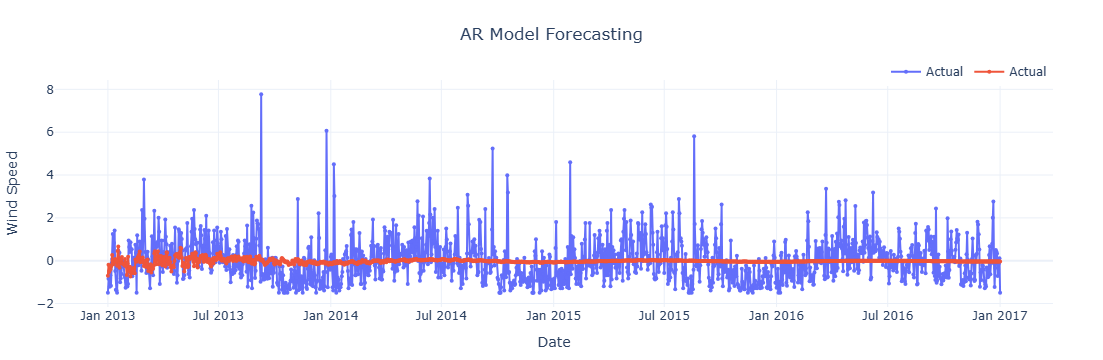

In [69]:
fig=go.Figure()
fig.add_trace(go.Scatter(x=wind_test.index, y=wind_test, mode="lines+markers", name="Actual"))
fig.add_trace(go.Scatter(x=wind_test.index, y=predictions, mode="lines+markers", name="Actual"))
fig.update_layout(title ="AR Model Forecasting", xaxis_title="Date", yaxis_title="Wind Speed", legend=dict(orientation="h", yanchor="top", y=1.1, 
                                                                                               xanchor="right", x=1), 
                  margin=dict(l=50, r=50, t=80, b=50),
                  template="plotly_white", title_x=0.5)
fig.update_traces(marker=dict(size=4))
fig.show()

In [70]:
print(wind_test)

date_train
2013-01-01   -1.491699
2013-01-02   -0.838196
2013-01-03   -0.475626
2013-01-04   -1.221233
2013-01-05   -0.680303
                ...   
2016-12-28   -0.713674
2016-12-29   -0.175921
2016-12-30   -0.117442
2016-12-31    0.114646
2017-01-01   -1.491699
Name: windspeed, Length: 1462, dtype: float64


In [71]:
print(predictions)

2017-01-02   -0.701832
2017-01-03   -0.189319
2017-01-04   -0.523228
2017-01-05   -0.448629
2017-01-06   -0.408211
                ...   
2020-12-29   -0.036227
2020-12-30   -0.036647
2020-12-31   -0.036469
2021-01-01   -0.036263
2021-01-02   -0.036244
Freq: D, Length: 1462, dtype: float64
